# TFG Dog Finder: Sistema de Búsqueda de Perros por Similitud Visual

Este Jupyter Notebook es el entorno principal para el desarrollo, prueba y evaluación del sistema "Dog Finder". Aquí se integran y demuestran las funcionalidades clave, desde la configuración inicial y la carga de datos, hasta la búsqueda de similitud visual y la evaluación del rendimiento.

El Notebook está estructurado en las siguientes secciones principales, diseñadas para guiar a través de la implementación y validación del sistema:

* **1. Preparación inicial y modelo:** Esta sección establece el entorno de ejecución, configura las dependencias necesarias y prepara el modelo de reconocimiento de imágenes. Su ejecución exitosa es un prerrequisito para todas las demás pruebas y funcionalidades del sistema.
* **2. Pruebas funcionales clave y carga de datos:** Esta sección consolida la verificación de múltiples requisitos interrelacionados, incluyendo el registro automático de imágenes (RF1), la detección de duplicados (RF2), la gestión del índice de búsqueda FAISS (RF4), la disponibilidad de datos (RNF5) y la persistencia de la información (RNF6). Las pruebas se realizan de forma secuencial para simular un flujo de trabajo real y observar la interacción entre los componentes.
* **3. Pruebas de búsqueda de similitud (demostración RF3):** Dedicada a validar la funcionalidad central del sistema, esta sección demuestra cómo el sistema permite buscar perros visualmente similares. Se verifica la entrada de consulta, la recuperación y el ordenamiento de los resultados, así como la aplicación de umbrales de similitud, como lo especifica el requisito RF3.
* **4. Evaluación de rendimiento y precisión (RNF1, RNF2, RNF7):** Este apartado finaliza la evaluación mediante la cuantificación del desempeño del sistema. Aquí se miden métricas críticas como la latencia de búsqueda y la escalabilidad del registro (RNF1), la precisión en la detección de duplicados (RNF2.1) y el F1-score en la búsqueda de similitud (RNF2.2). Además, se evalúa la optimización para entornos de recursos limitados (RNF7), consolidando la evidencia del cumplimiento de los atributos de calidad del sistema.

**Instrucciones de Uso:**
* Ejecuta las celdas de este Notebook secuencialmente, de arriba hacia abajo.
* Presta atención a los mensajes de salida para verificar los resultados de las pruebas.
* Modifica las rutas de los datasets y los nombres de las imágenes de prueba según sea necesario para adaptarlo a tu entorno.
* En caso de errores, consulta los mensajes de la consola y la documentación de los módulos (`.py` files).

## 1. Preparación inicial y modelo


### 1.1 Configuración inicial
Esta subsección se encarga de preparar el directorio de trabajo y asegurar que todas las librerías externas necesarias estén disponibles en el entorno.

#### Clonar repositorio y cambiar directorio

In [6]:
# Borra el repositorio si ya existe, para evitar errores al clonar
# Comenta estas líneas si ya has clonado el repositorio y estás en el directorio correcto.
!rm -rf TFG-DogFinderV2
!git clone https://github.com/dasniela/TFG-DogFinderV2.git

import os
# Asegúrate de que este sea el directorio correcto donde clonaste tu repositorio.
# Si ya estás en el directorio raíz del TFG-DogFinder, puedes comentar esta línea.
# os.chdir('TFG-DogFinderV2') 

print("Directorio actual:", os.getcwd())
print("Contenido:", os.listdir('.'))


Directorio actual: /Users/dasniela/CascadeProjects/TFG-DogFinderV2
Contenido: ['add_dogs_to_db.py', 'dog_finder_demo_v4.db', '.DS_Store', 'dog_id_map.json', 'Tsinghua_Dogs_Dataset', 'Dog_Mx_Dataset', 'dog_features.faiss', 'dog_groups.json', 'TFG_DogFinder_FeatureExtraction .ipynb', '__pycache__', 'README.md', 'Stanford_images', '.ipynb_checkpoints', 'common_dog_finder_config.py']


#### Instalación de librerías

In [51]:
# Instala todas las librerías necesarias para el proyecto.
#pip install tensorflow sqlalchemy matplotlib faiss-cpu

!pip install tensorflow sqlalchemy matplotlib faiss-cpu

print("Librerías instaladas o ya existentes.")

Librerías instaladas o ya existentes.


### 1.2. Importaciones y recarga de módulos

Esta subsección se asegura de cargar todas las bibliotecas de Python y los módulos personalizados del proyecto, garantizando que estén actualizados y disponibles para su uso en las celdas posteriores.

Las funcionalidades principales del sistema, como el modelo de reconocimiento, las operaciones de base de datos y la gestión del índice FAISS, están encapsuladas en módulos Python 
- `common_dog_finder_config.py`
- `add_dogs_to_db.py`).

Esta celda se encarga de:

* Importar las bibliotecas.
* Recargar los módulos personalizados (`common_dog_finder_config` y `add_dogs_to_db`) si han sido modificados durante la sesión de Jupyter. 
* Importar clases y funciones específicas necesarias de estos módulos para su uso directo en el Notebook.

**Nota Importante:** Las definiciones de clases y funciones principales como `DogRecognitionModel`, `Dog`, `is_duplicate_image_by_features`, `show_image`, `search_similar_dogs`, y las configuraciones de la base de datos (`DB_PATH`, `IMAGE_DIRS`, `session`) se encuentran en el archivo `common_dog_finder_config.py`. Las importaremos desde allí para mantener el código modular y evitar duplicidades.

In [53]:
# Importa las bibliotecas principales que el notebook podría necesitar directamente
import os
import numpy as np
import tensorflow as tf # Se mantiene por si se usa alguna funcionalidad directa de TF/Keras
import cv2
import json
import matplotlib.pyplot as plt
import importlib
import sys

# Lista de módulos a recargar, útil para aplicar los cambios sin reiniciar el kernel
modules_to_reload = ['common_dog_finder_config', 'add_dogs_to_db']

for module_name in modules_to_reload:
    if module_name in sys.modules: # Solo recargar si ya ha sido importado antes
        try:
            importlib.reload(sys.modules[module_name])
            print(f"Módulo '{module_name}' recargado exitosamente.")
        except Exception as e:
            print(f"Error al recargar el módulo '{module_name}': {e}")

# Importar funcionalidades específicas de los módulos de configuración y lógica (common_dog_finder_config)
from common_dog_finder_config import (
    DogRecognitionModel, Dog,
    DB_PATH, IMAGE_DIRS, TEST_IMAGE_DIRS,
    session,
    is_duplicate_image_by_features, show_image, search_similar_dogs,
    reset_database,
    initialize_faiss_index_from_db, 
    FAISS_INDEX_PATH,
    FAISS_ID_MAP_PATH,
    DUPLICATE_THRESHOLD_SIMILARITY, 
)
# Importar add_images_to_database  (add_dogs_to_db)
from add_dogs_to_db import add_images_to_database

print("Funcionalidades cargadas desde common_dog_finder_config.py y add_dogs_to_db.py")

Módulo 'common_dog_finder_config' recargado exitosamente.
Módulo 'add_dogs_to_db' recargado exitosamente.
Funcionalidades cargadas desde common_dog_finder_config.py y add_dogs_to_db.py


### 1.3 Implementación del modelo como Extractor de Caracteristicas

En esta subsección se presenta la inicialización del modelo de aprendizaje profundo encargado de transformar las imágenes de perros en vectores numéricos. Esta representación constituye la base del sistema de similitud, al capturar las características más distintivas de cada imagen.

La clase `DogRecognitionModel`, definida en `common_dog_finder_config.py`, encapsula esta funcionalidad. Se utiliza la arquitectura **MobileNetV2** debido a su eficiencia y su capacidad de Transfer Learning. El modelo se adapta para la extracción de características mediante:

* **Carga de Pesos Pre-entrenados:** Utiliza pesos de ImageNet para aprovechar el conocimiento previo.
* **Congelamiento de Capas:** Las capas pre-entrenadas se "congelan" para actuar como un extractor fijo, evitando el sobreajuste con datasets más pequeños.
* **Eliminación de la Capa de Clasificación (`include_top=False`):** Se suprime la capa final, ya que no se busca clasificar imágenes, sino obtener un vector de características general.
* **Global Average Pooling (`pooling='avg'`):** Transforma la salida convolucional en un vector de características de tamaño fijo (1280 dimensiones).

Además, la clase `DogRecognitionModel` incluye métodos para el **preprocesamiento de imágenes** (carga, conversión BGR a RGB, redimensionamiento a 224x224, conversión a `float32`, expansión de dimensiones y normalización específica de MobileNetV2) y para la **generación de embeddings L2 normalizados**, asegurando que los vectores sean comparables por similitud coseno.



In [56]:
# Crea una instancia de DogRecognitionModel.
# Esto carga el modelo MobileNetV2 en memoria y lo prepara para extraer características.
model = DogRecognitionModel()
print("Instancia de DogRecognitionModel creada y modelo de extracción de características listo.")

Instancia de DogRecognitionModel creada y modelo de extracción de características listo.


### 1.4 Implementación de la Base de Datos
Esta subsección detalla la configuración de la base de datos SQLite con SQLAlchemy, la definición de su esquema y la preparación del índice FAISS, componentes esenciales para el almacenamiento y la búsqueda eficiente.

#### Diseño de la Base de Datos
Para el almacenamiento persistente de la información de los perros y sus características, se utiliza **SQLite** como sistema de gestión de base de datos (SGBD) y **SQLAlchemy** como Object-Relational Mapper (ORM). Esta combinación ofrece portabilidad, facilidad de configuración y una interacción orientada a objetos desde Python.

La información se estructura en una única tabla principal llamada `dogs`, con los siguientes campos:

* **id:** Identificador único para cada registro (clave primaria, autoincremental).
* **name:** Nombre del perro o, por defecto, el nombre del archivo de imagen.
* **location:** Texto que representa la ubicación donde fue encontrado el perro.
* **found_date:** Fecha y hora en que se registró el perro.
* **image_path:** Ruta local completa de la imagen asociada al perro (debe ser única).
* **features:** Vector de características (embedding) extraído de la imagen, almacenado como una cadena en formato JSON.

#### Configuración de la base de datos con SQLAlchemy

In [62]:
# La base de datos, el motor (engine) y la sesión (session) de SQLAlchemy
# se inicializan automáticamente al importar common_dog_finder_config.py.
# 'session' es la instancia global para todas las operaciones de la BD.
print(f"Conectado a la base de datos: {DB_PATH}")
print("La tabla 'dogs' ha sido creada/verificada.")

# Inicializa el índice FAISS para esta sesión del notebook.
# Esto intentará cargar el índice desde disco. Si no existe o hay un problema,
# lo reconstruirá desde la base de datos SQLite y lo guardará.
print("Inicializando índice FAISS para búsquedas y detección de duplicados...")
initialize_faiss_index_from_db()
print("Índice FAISS listo para usar.")

# Muestra el número actual de imágenes en la base de datos al inicio.
total_images_at_start = session.query(Dog).count()
print(f"Total de imágenes en la base de datos al inicio: {total_images_at_start}")

Conectado a la base de datos: sqlite:///dog_finder_demo_v4.db
La tabla 'dogs' ha sido creada/verificada.
Inicializando índice FAISS para búsquedas y detección de duplicados...
Índice FAISS cargado desde dog_features.faiss con 20755 vectores.
Mapeo de IDs cargado desde dog_id_map.json.
Índice FAISS cargado y sincronizado con la base de datos.
Índice FAISS listo para usar.
Total de imágenes en la base de datos al inicio: 20755


## 2. Pruebas funcionales y carga de datos

Esta sección consolida las pruebas de **registro automático de imágenes (RF1)**, **detección de duplicados (RF2)**, **gestión del índice de búsqueda (RF4)**, **disponibilidad de datos (RNF5)** y **persistencia (RNF6)**. El objetivo es verificar el flujo completo de adición de imágenes, la correcta gestión de duplicados y del índice FAISS, y la persistencia de los datos entre sesiones.

--- INCIANDO: Pruebas funcionales y carga de datos---
--- Requisitos relacionados: RF1, RF2, RF4, RNF5, RNF6---

=== 2.1 Carga Inicial de Imágenes y Persistencia ===
Objetivo: Verificar el registro automático, creación y persistencia de la DB y FAISS.

Acción: Reseteando la base de datos para una prueba de carga inicial limpia...
Borrando todos los registros de la tabla 'dogs'...
Registros borrados.
Archivo de índice FAISS 'dog_features.faiss' borrado.
Archivo de mapeo de IDs 'dog_id_map.json' borrado.
Base de datos e índice FAISS reiniciados.
Acción: Añadiendo imágenes desde ['Stanford_images', 'Dog_Mx_Dataset'] por primera vez (incluye detección de duplicados por características)...
Reconstruyendo índice FAISS desde la base de datos...
Base de datos vacía o sin características válidas, no se puede construir índice FAISS. Borrando archivos de índice si existen.
DEBUG: Índice de batch iniciado vacío, ya que la DB existente está vacía.
Iniciando procesamiento de imágenes...
Se añadieron

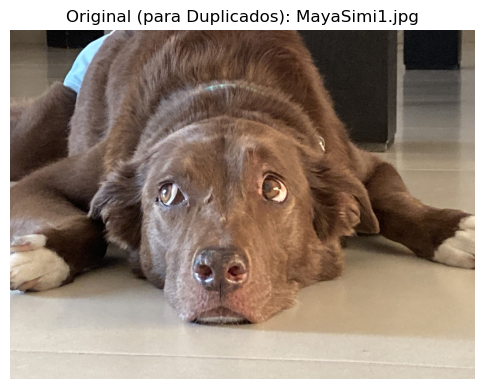

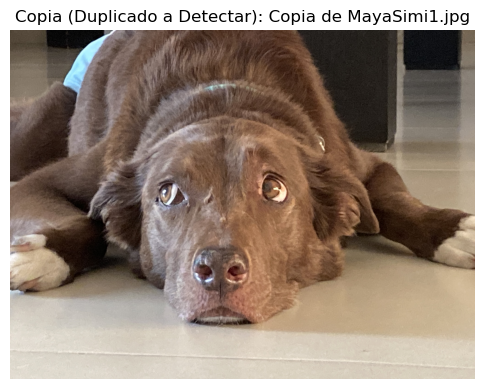


  Similitud coseno real entre original y copia: 1.00
  Umbral de detección de duplicados (DUPLICATE_THRESHOLD_SIMILARITY): 0.95
  Criterio RF2.2/RF2.3/RF2.4/RNF2.1: ¡ÉXITO! La copia fue detectada como DUPLICADO por caracteristicas con el umbral configurado.
  (Similitud 1.0000 >= Umbral 0.95)

  Acción: Intentando añadir 'Copia de MayaSimi1.jpg' de nuevo para observar contadores...
Índice FAISS cargado desde dog_features.faiss con 20755 vectores.
Mapeo de IDs cargado desde dog_id_map.json.
Índice FAISS cargado y sincronizado con la base de datos.
DEBUG: Índice de batch inicializado con 20755 elementos de la DB existente.
Iniciando procesamiento de imágenes...
No se añadieron nuevas imágenes en este lote. El índice FAISS global no necesita reconstruirse.

--- Resumen del procesamiento ---
Nuevas imágenes añadidas a la BD: 0
Imágenes omitidas (ya existen por ruta): 313
Imágenes omitidas (duplicados por características): 1
  (Verifique en la salida de 'add_images_to_database' que Imagene

In [65]:
# Pruebas de registro, duplicados, gestión de índice y persistencia

print("--- INCIANDO: Pruebas funcionales y carga de datos---")
print("--- Requisitos relacionados: RF1, RF2, RF4, RNF5, RNF6---")

import os
import json
import faiss 
import numpy as np 
import cv2 

# --- 2.1 Prueba de Carga Inicial de Imagenes y Persistencia ---
print("\n=== 2.1 Carga Inicial de Imágenes y Persistencia ===")
print("Objetivo: Verificar el registro automático, creación y persistencia de la DB y FAISS.")

print("\nAcción: Reseteando la base de datos para una prueba de carga inicial limpia...")
reset_database()
from common_dog_finder_config import Session 
session = Session() 

# Importante: se usa IMAGE_DIRS (que contiene Stanford y Dog_Mx) para la carga inicial.
# Esto es esencial porque los duplicados existentes en tus datasets grandes se detectarán aquí,
# y esta carga servirá como base para la prueba de duplicados por ruta en el Paso 2.
print(f"Acción: Añadiendo imágenes desde {IMAGE_DIRS} por primera vez (incluye detección de duplicados por características)...")
add_images_to_database(IMAGE_DIRS) 

# Conteo de imágenes esperadas en disco para verificación (RF1.1, RNF5.1)
expected_images_on_disk = 0
for img_dir in IMAGE_DIRS:
    if os.path.exists(img_dir): 
        for root, _, files in os.walk(img_dir):
            for fname in files:
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')): # RF1.1: Validación de Formato
                    expected_images_on_disk += 1
    else:
        print(f"Advertencia: Directorio '{img_dir}' no encontrado. No se contará para el total esperado.")

actual_images_in_db_count_after_initial_load = session.query(Dog).count() # RF1.3: Almacenamiento en DB
faiss_index_created_initial = os.path.exists(FAISS_INDEX_PATH) # RF4.2: Persistencia del indice
faiss_id_map_created_initial = os.path.exists(FAISS_ID_MAP_PATH) # RF4.2: Persistencia del indice

print(f"\nResultados de Carga Inicial:")
print(f"  Imágenes esperadas en disco (total): {expected_images_on_disk}")
print(f"  Imágenes añadidas a la DB (después de omitir duplicados internos): {actual_images_in_db_count_after_initial_load}")
print(f"  Archivos FAISS creados: {faiss_index_created_initial} (Index), {faiss_id_map_created_initial} (ID Map)")

# Criterio de exito de carga inicial
if actual_images_in_db_count_after_initial_load > 0 and faiss_index_created_initial and faiss_id_map_created_initial:
    print("  Criterio RF1 / RF4.1/RF4.2 / RNF5.1 / RNF6: ¡ÉXITO!")
    print("  Imagenes añadidas, FAISS creado/guardado, datos accesibles. Proceso de registro inicial exitoso.")
    try:
        loaded_index_count_initial = faiss.read_index(FAISS_INDEX_PATH).ntotal 
        if loaded_index_count_initial == actual_images_in_db_count_after_initial_load:
            print("  FAISS Index count coincide con DB count. Persistencia inicial verificada.") # RF4.3 (carga aquí)
        else:
            print("  ADVERTENCIA: Conteo de FAISS no coincide con DB. Posible desincronización inicial.")
    except Exception as e:
        print(f"  ERROR: Fallo al verificar FAISS cargado inicialmente: {e}")
else:
    print("  Criterio RF1 / RF4.1/RF4.2 / RNF5.1 / RNF6: ¡FALLO! Revisar logs para errores o conteo de imágenes.")


# --- 2.2.1: Prueba de detección de duplicados por ruta ---
print("\n=== 2.2.1 Deteccion de duplicados por ruta ===")
print("Objetivo: Verificar que se omiten imagenes cuya ruta de archivo ya exista en la DB.")

# Simulación del intento de añadir las MISMAS imágenes de nuevo.
# Dado que la BD ya está poblada con las imágenes de IMAGE_DIRS (del Paso 1),
# al intentar añadir el MISMO conjunto de directorios, el sistema debería detectar
# las imágenes por su ruta exacta y omitirlas.
print(f"Acción: Intentando añadir el MISMO conjunto de imágenes desde {IMAGE_DIRS} de nuevo sin resetear la DB...")
add_images_to_database(IMAGE_DIRS) # Vuelve a procesar los directorios.

final_db_count_after_route_check = session.query(Dog).count()
print(f"  Imágenes en BD después del segundo intento de adición por ruta: {final_db_count_after_route_check}")

# El número de imágenes en la DB no debería haber cambiado si la detección por ruta funciona correctamente.
if final_db_count_after_route_check == actual_images_in_db_count_after_initial_load:
    print("  Criterio RF2.1 - Duplicados por ruta: ¡ÉXITO! No se añadieron nuevas imágenes ya existentes por ruta.")
    print("  (Verifique en la salida detallada de 'add_images_to_database' justo arriba que el contador Imágenes omitidas (ya existen por ruta)' sea alto y que Nuevas imágenes añadidas a la DB sea 0).")
else:
    print("  Criterio RF2.1 - Duplicados por ruta: ¡FALLO! Se añadieron imágenes que ya existian por ruta.")
    print("  Esto indica un problema en la detección de duplicados por ruta.")


# --- 2.2.3: Prueba de deteccion de duplicados por caracteristicas  ---
print("\n=== 2.2.3 Detección de duplicados por caracteristicas ===")
print("Objetivo: Verificar la detección de duplicados visuales, el uso del umbral y contribuir a la precision")

# La prueba de 'Copia de MayaSimi1.jpg' demostrará RF2.2/RF2.3 y el impacto del umbral (RF2.4/RNF2.1).
print("\nAccion: Demostracion explícita de deteccion de duplicados con una copia conocida.")
original_test_image = os.path.join(TEST_IMAGE_DIRS[0], 'MayaSimi1.jpg') 
copied_test_image = os.path.join(TEST_IMAGE_DIRS[0], 'Copia de MayaSimi1.jpg') 

if not os.path.exists(original_test_image) or not os.path.exists(copied_test_image):
    print(f"  ERROR: Una o ambas imágenes de prueba para demostración de duplicados no existen:")
    print(f"    Original: {original_test_image} (Existe: {os.path.exists(original_test_image)})")
    print(f"    Copia: {copied_test_image} (Existe: {os.path.exists(copied_test_image)})")
else:
    show_image(original_test_image, title=f"Original (para Duplicados): {os.path.basename(original_test_image)}")
    show_image(copied_test_image, title=f"Copia (Duplicado a Detectar): {os.path.basename(copied_test_image)}")

    try:
        processed_copied_img = model.preprocess_image(copied_test_image)
        features_copy = model.extract_features(processed_copied_img)

        processed_original_img = model.preprocess_image(original_test_image)
        features_original = model.extract_features(processed_original_img)
        real_similarity = np.dot(features_original.flatten(), features_copy.flatten())
        
        is_detected_as_duplicate_explicit = is_duplicate_image_by_features(features_copy, threshold=DUPLICATE_THRESHOLD_SIMILARITY)
        
        print(f"\n  Similitud coseno real entre original y copia: {real_similarity:.2f}")
        print(f"  Umbral de detección de duplicados (DUPLICATE_THRESHOLD_SIMILARITY): {DUPLICATE_THRESHOLD_SIMILARITY}")

        if is_detected_as_duplicate_explicit:
            print("  Criterio RF2.2/RF2.3/RF2.4/RNF2.1: ¡ÉXITO! La copia fue detectada como DUPLICADO por caracteristicas con el umbral configurado.")
            print(f"  (Similitud {real_similarity:.4f} >= Umbral {DUPLICATE_THRESHOLD_SIMILARITY})")
        else:
            print("  Criterio RF2.2/RF2.3/RF2.4/RNF2.1: ¡FALLO! La copia NO fue detectada como DUPLICADO por caracteristicas con el umbral configurado.")
            print(f"  (Similitud {real_similarity:.4f} < Umbral {DUPLICATE_THRESHOLD_SIMILARITY})")
            print("  Considere ajustar 'DUPLICATE_THRESHOLD_SIMILARITY' en common_dog_finder_config.py.")
            print(f"  Para que esta copia se detecte como duplicado, el umbral debería ser <= {real_similarity:.4f}.")
            
        print(f"\n  Acción: Intentando añadir '{os.path.basename(copied_test_image)}' de nuevo para observar contadores...")
        # Esta adición probará si la copia se omite por características (RF2.2/RF2.3) y reportará en los contadores.
        add_images_to_database([os.path.dirname(copied_test_image)])
        print("  (Verifique en la salida de 'add_images_to_database' que Imagenes omitidas (duplicados por características) aumentó.)")

    except Exception as e:
        print(f"ERROR: Ocurrió un error durante la demostración explícita de duplicados: {e}")
        print("Verifica que las rutas de las imágenes de prueba son correctas y los archivos existen.")


 # --- 2.2.4:Prueba de carga/sincronización del indice FAISS (RF4.3, RF4.4) ---
print("\n=== 2.2.4 Carga y sincronización del indice FAISS ===")
print("Objetivo: Verificar que FAISS carga desde disco y se sincroniza al añadir nuevas imágenes.")

# Verificacion de carga desde cisco (RF4.3)
print("\nAcción: Reinicializando el índice FAISS global para verificar la carga desde disco...")
global faiss_index_global 
global faiss_id_map_global 
faiss_index_global = None
faiss_id_map_global = []
initialize_faiss_index_from_db() # Esta llamada debería imprimir "Índice FAISS cargado..."

current_db_count_rf4_step4_1 = session.query(Dog).count()
if os.path.exists(FAISS_INDEX_PATH) and os.path.exists(FAISS_ID_MAP_PATH) and current_db_count_rf4_step4_1 > 0:
    try:
        loaded_index_rf4_step4_1 = faiss.read_index(FAISS_INDEX_PATH)
        if loaded_index_rf4_step4_1.ntotal == current_db_count_rf4_step4_1:
            print("  Criterio RF4.3 - Carga del indice: ¡ÉXITO! El índice FAISS se cargo correctamente desde disco y ests sincronizado.")
        else:
            print("  Criterio RF4.3 - Carga del indice: ¡FALLO! El índice se cargo pero no está sincronizado (FAISS:{} vs DB:{}).".format(loaded_index_rf4_step4_1.ntotal, current_db_count_rf4_step4_1))
    except Exception as e:
        print(f"  Criterio RF4.3 - Carga del Índice: ¡FALLO! Error al cargar o verificar el índice desde disco: {e}")
else:
    print("  Criterio RF4.3 - Carga del indice: ¡FALLO! No hay archivos de índice para cargar o la DB esta vacia.")
    print("  Verifica que el Paso 1 se ejecutó correctamente.")

# Verificacion de sincronización tras adición (RF4.4)
print("\nAccion: Preparando y añadiendo nuevas imagenes para probar sincronización...")
# El directorio NEW_IMAGES_DIR_RF4 contiene 4 imágenes nuevas
NEW_IMAGES_DIR_RF4 = "NEW_IMAGES_DIR_RF4" # Nombre del directorio existente del usuario

if not os.path.exists(NEW_IMAGES_DIR_RF4) or not any(fname.lower().endswith(('.jpg', '.jpeg', '.png')) for fname in os.listdir(NEW_IMAGES_DIR_RF4)):
    print(f"  ADVERTENCIA: El directorio '{NEW_IMAGES_DIR_RF4}' no existe o esta vacío. La prueba de sincronización RF4.4 no puede ejecutarse correctamente.")
else:
    db_count_before_new_add = session.query(Dog).count()
    print(f"  Imagenes en DB antes de añadir nuevas: {db_count_before_new_add}")

    add_images_to_database([NEW_IMAGES_DIR_RF4]) 
    
    db_count_after_new_add_rf4 = session.query(Dog).count()
    print(f"  Imágenes en DB despues de añadir nuevas: {db_count_after_new_add_rf4}")

    if os.path.exists(FAISS_INDEX_PATH) and os.path.exists(FAISS_ID_MAP_PATH):
        try:
            loaded_index_final_rf4 = faiss.read_index(FAISS_INDEX_PATH)
            if loaded_index_final_rf4.ntotal == db_count_after_new_add_rf4:
                print("  Criterio RF4.4 - Sincronización FAISS: ¡ÉXITO! FAISS se reconstruyo y sincronizo.")
                print(f"    (FAISS: {loaded_index_final_rf4.ntotal} vectores == DB: {db_count_after_new_add_rf4} registros)")
            else:
                print("  Criterio RF4.4 - Sincronización FAISS: ¡FALLO! Conteo de FAISS ({}) NO coincide con DB ({}).".format(loaded_index_final_rf4.ntotal, db_count_after_new_add_rf4))
        except Exception as e:
            print(f"  Criterio RF4.4 - Sincronización FAISS: ¡FALLO! Error al verificar el índice final: {e}")
    else:
        print("  Criterio RF4.4 - Sincronización FAISS: ¡FALLO! Archivos FAISS no encontrados después de la adicion.")

print("\n=== FIN: Pruebas funcionales y carga de datos===")

## 3. Pruebas de búsqueda de similitud 
Esta sección realiza la prueba funcional del sistema de búsqueda de perros similares (RF3). Se verifica que el sistema puede tomar una imagen de consulta, encontrar perros visualmente parecidos en la base de datos, y presentar los resultados de forma coherente y ordenada.



--- INICIANDO: Pruebas de búsqueda de similitud ---
--- Requisitos relacionados: RF3 ---

===Procesamiento de la imagen de consulta (RF3.1) ===
Objetivo: Verificar que el sistema acepta una imagen como consulta para la búsqueda.

Acción: Seleccionando imagen de búsqueda: Dog_Mx_Dataset/oliver2.jpg


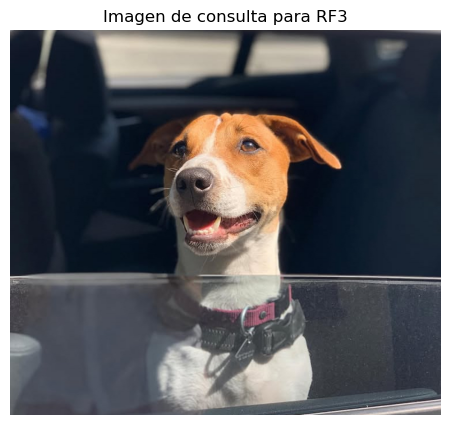

Acción: Extrayendo características de la imagen de búsqueda...
Características de la imagen de búsqueda extraídas.

=== Obtener ID para xxclusión (RF3.1/RF3.2) ===
Acción: Buscando imagen de consulta en la DB para posible exclusión (previene auto-coincidencia).
  ID de la imagen de búsqueda para excluir de los resultados: 20670

=== Recuperación de resultados y umbral (RF3.2, RF3.4) ===
Objetivo: Verificar que se recuperan resultados que superan un umbral de similitud.
Acción: Realizando búsqueda de perros similares en el índice FAISS...

=== Ordenamiento y visualización de resultados (RF3.3) ===
Objetivo: Verificar que los resultados están ordenados y son coherentes.

=== Resultados de la Búsqueda RF3: 15 coincidencias encontradas ===

Detalles de las coincidencias:
Coincidencia #1
  ID: 7193
  Similitud Coseno: 69.99%
  Nombre: n02089973_1232.jpg
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:42:35.567617
  Ruta imagen: Stanford_images/n02089973_1232.jpg


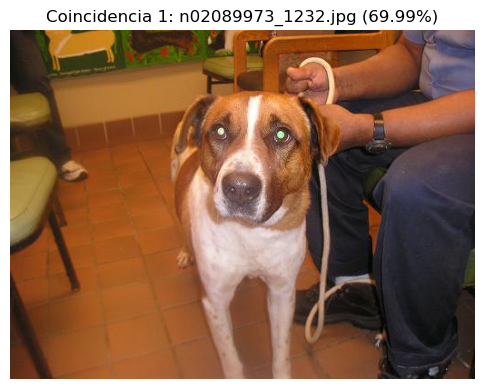

------------------------------
Coincidencia #2
  ID: 20633
  Similitud Coseno: 69.92%
  Nombre: oliver5.jpg
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:49:29.636520
  Ruta imagen: Dog_Mx_Dataset/oliver5.jpg


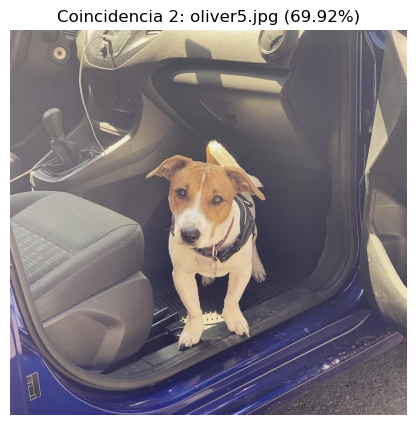

------------------------------
Coincidencia #3
  ID: 13967
  Similitud Coseno: 69.32%
  Nombre: n02089867_426.jpg
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:45:59.022873
  Ruta imagen: Stanford_images/n02089867_426.jpg


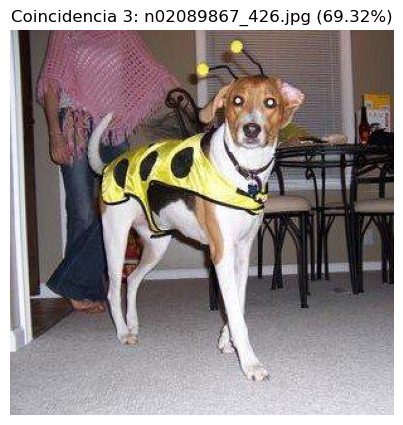

------------------------------
Coincidencia #4
  ID: 4676
  Similitud Coseno: 67.94%
  Nombre: n02107908_6683.jpg
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:41:20.419936
  Ruta imagen: Stanford_images/n02107908_6683.jpg


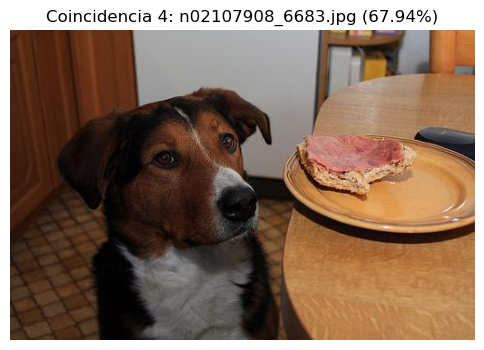

------------------------------
Coincidencia #5
  ID: 4998
  Similitud Coseno: 66.59%
  Nombre: n02089973_1492.jpg
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:41:30.185379
  Ruta imagen: Stanford_images/n02089973_1492.jpg


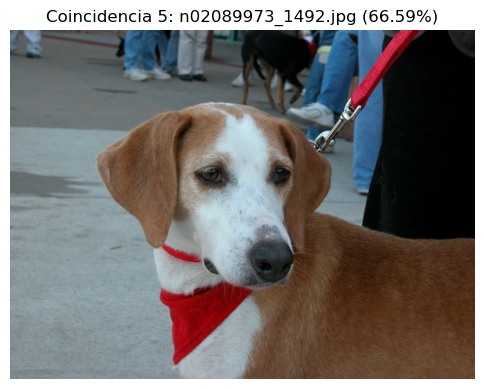

------------------------------
Coincidencia #6
  ID: 20621
  Similitud Coseno: 66.38%
  Nombre: nita5.JPG
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:49:29.006593
  Ruta imagen: Dog_Mx_Dataset/nita5.JPG


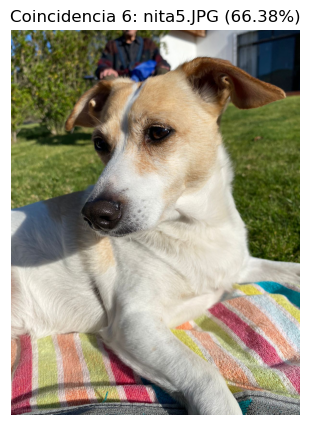

------------------------------
Coincidencia #7
  ID: 1572
  Similitud Coseno: 66.26%
  Nombre: n02089867_91.jpg
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:39:49.351628
  Ruta imagen: Stanford_images/n02089867_91.jpg


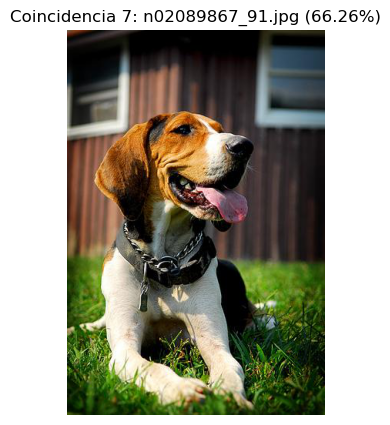

------------------------------
Coincidencia #8
  ID: 9166
  Similitud Coseno: 65.78%
  Nombre: n02089867_1620.jpg
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:43:34.263401
  Ruta imagen: Stanford_images/n02089867_1620.jpg


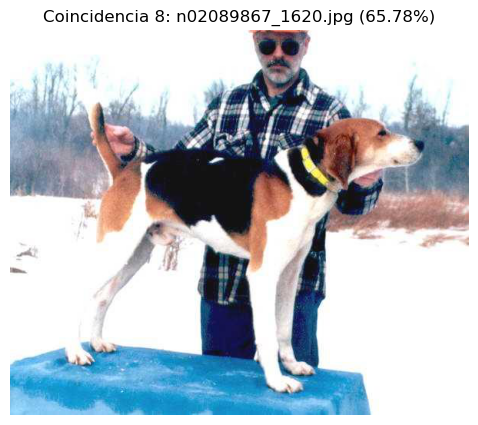

------------------------------
Coincidencia #9
  ID: 15915
  Similitud Coseno: 65.36%
  Nombre: n02091032_55.jpg
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:46:58.603701
  Ruta imagen: Stanford_images/n02091032_55.jpg


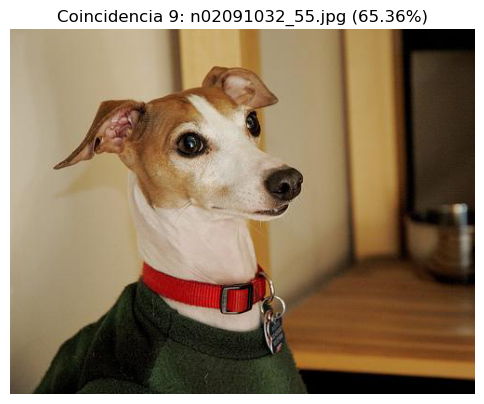

------------------------------
Coincidencia #10
  ID: 5146
  Similitud Coseno: 65.07%
  Nombre: n02107908_5017.jpg
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:41:34.642118
  Ruta imagen: Stanford_images/n02107908_5017.jpg


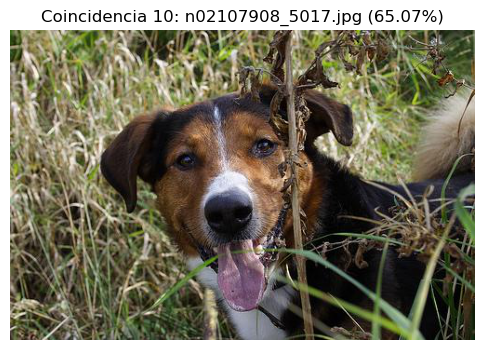

------------------------------
Coincidencia #11
  ID: 6418
  Similitud Coseno: 64.81%
  Nombre: n02088364_17474.jpg
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:42:12.493407
  Ruta imagen: Stanford_images/n02088364_17474.jpg


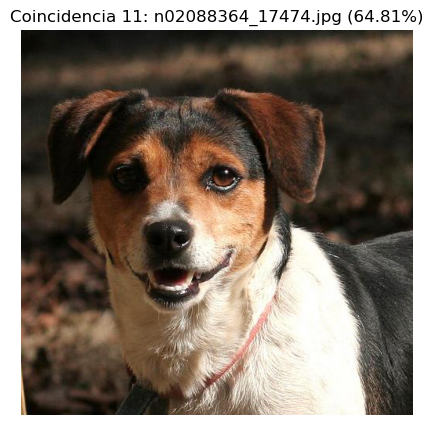

------------------------------
Coincidencia #12
  ID: 2189
  Similitud Coseno: 64.65%
  Nombre: n02089867_1240.jpg
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:40:07.121816
  Ruta imagen: Stanford_images/n02089867_1240.jpg


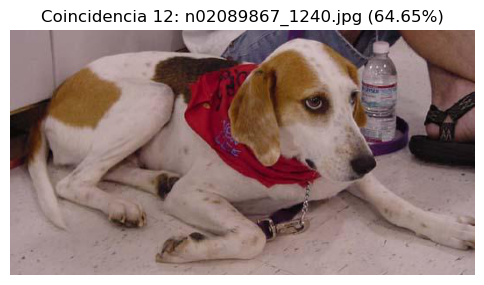

------------------------------
Coincidencia #13
  ID: 11686
  Similitud Coseno: 64.64%
  Nombre: n02089867_146.jpg
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:44:49.730677
  Ruta imagen: Stanford_images/n02089867_146.jpg


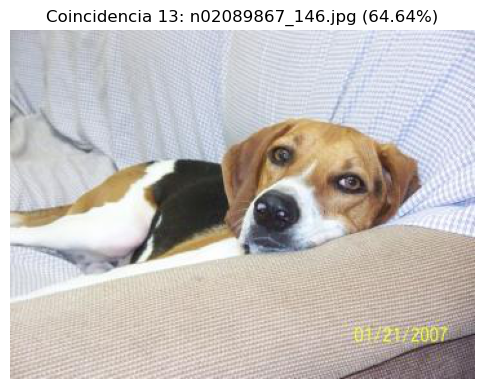

------------------------------
Coincidencia #14
  ID: 20625
  Similitud Coseno: 64.50%
  Nombre: nita4.JPG
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:49:29.213971
  Ruta imagen: Dog_Mx_Dataset/nita4.JPG


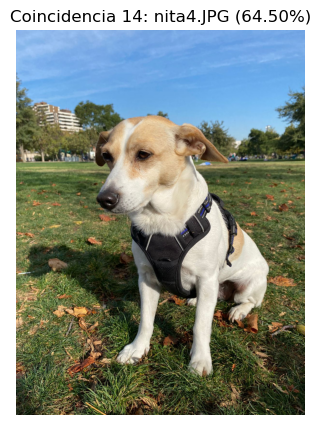

------------------------------
Coincidencia #15
  ID: 11372
  Similitud Coseno: 63.97%
  Nombre: n02110806_2157.jpg
  Ubicación: Desconocida
  Fecha: 2025-07-06 18:44:40.084864
  Ruta imagen: Stanford_images/n02110806_2157.jpg


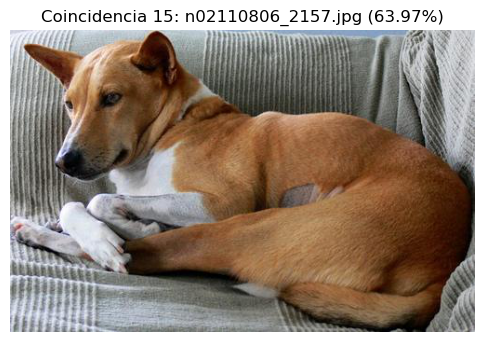

------------------------------

=== Verificación de Criterios de Éxito para RF3 ===
  Criterio RF3 - Recuperación de resultados: ¡ÉXITO! Se encontraron resultados.
  Criterio RF3.3 - Ordenamiento de resultados: ¡ÉXITO! Los resultados están ordenados de mayor a menor similitud.
  Criterio RF3 - Exclusión de imagen de consulta: ¡ÉXITO! La imagen de consulta fue excluida correctamente.

=== FIN: Pruebas de búsqueda de similitud (Demostración RF3) ===


In [79]:
# Prueba de búsqueda de perros similares 

print(""f"\n--- INICIANDO: Pruebas de búsqueda de similitud ---")
print("--- Requisitos relacionados: RF3 ---")


# --- PASO 1: Definición y Extracción de Características de la Imagen de Consulta (RF3.1) ---
print("\n===Procesamiento de la imagen de consulta (RF3.1) ===")
print("Objetivo: Verificar que el sistema acepta una imagen como consulta para la búsqueda.")

# Selecciona una imagen de prueba como consulta
test_image_path = os.path.join(IMAGE_DIRS[1], 'oliver2.jpg') 

#3.5 Pruebas de imagenes desafiantes
#test_images_limitations es un directorio con imagenes consideradas dificiles de detectar
#test_images_limitations = "test_images_limitations"
#test_image_path = os.path.join(test_images_limitations, 'badquality2.jpg') 

print(f"\nAcción: Seleccionando imagen de búsqueda: {test_image_path}")
show_image(test_image_path, title="Imagen de consulta para RF3")

print("Acción: Extrayendo características de la imagen de búsqueda...")
preprocessed_query_img = model.preprocess_image(test_image_path)
if preprocessed_query_img is None:
    print(f"ERROR: No se pudo preprocesar la imagen de consulta '{test_image_path}'. La prueba no puede continuar.")
    exit_rf3_test = True # Bandera para saltar el resto de la prueba
else:
    query_features = model.extract_features(preprocessed_query_img)
    print("Características de la imagen de búsqueda extraídas.")
    exit_rf3_test = False

if not exit_rf3_test:
    # --- PASO 2: Obtener el ID de la imagen de consulta para excluirla (RF3.1/RF3.2) ---
    print("\n=== Obtener ID para xxclusión (RF3.1/RF3.2) ===")
    print("Acción: Buscando imagen de consulta en la DB para posible exclusión (previene auto-coincidencia).")
    query_dog_in_db = session.query(Dog).filter_by(image_path=test_image_path).first()
    exclude_id = query_dog_in_db.id if query_dog_in_db else None

    if exclude_id:
        print(f"  ID de la imagen de búsqueda para excluir de los resultados: {exclude_id}")
        exclusion_check_success = True
    else:
        print("  ADVERTENCIA: La imagen de búsqueda no se encontró en la base de datos. No se podrá excluir de los resultados.")
        exclusion_check_success = False

    # --- PASO 3: Realizar la búsqueda de perros similares (RF3.2, RF3.4) ---
    print("\n=== Recuperación de resultados y umbral (RF3.2, RF3.4) ===")
    print("Objetivo: Verificar que se recuperan resultados que superan un umbral de similitud.")

    print("Acción: Realizando búsqueda de perros similares en el índice FAISS...")
    # k=15: Se solicitan hasta 15 resultados más cercanos.
    # threshold_ip=0.50: Se utiliza un umbral de similitud coseno de 0.50.
    # exclude_dog_id: Se pasa el ID de la imagen de consulta para que sea omitida de los resultados.
    similar_dogs = search_similar_dogs(
        query_features, 
        k=15, 
        threshold_ip=0.50, # Usando threshold_ip (similitud coseno) según common_dog_finder_config.py
        exclude_dog_id=exclude_id 
    )

    # --- 3.4: Observar y verificar resultados (RF3.3) ---
    print("\n=== Ordenamiento y visualización de resultados (RF3.3) ===")
    print("Objetivo: Verificar que los resultados están ordenados y son coherentes.")
    
    if similar_dogs:
        print(f"\n=== Resultados de la Búsqueda RF3: {len(similar_dogs)} coincidencias encontradas ===\n")
        
        # Criterio de éxito: Resultados de búsqueda coherentes y ordenamiento correcto.
        is_sorted_descending = True
        for i in range(len(similar_dogs) - 1):
            if similar_dogs[i]['similarity'] < similar_dogs[i+1]['similarity']:
                is_sorted_descending = False
                break
        
        print("Detalles de las coincidencias:")
        for i, result in enumerate(similar_dogs):
            if i >= 15: # Limitar la visualización para no saturar el output
                print(f"... y {len(similar_dogs) - i} coincidencias más.")
                break
            print(f"Coincidencia #{i+1}")
            print(f"  ID: {result['dog_id']}") # Usar 'dog_id' según la función de search_similar_dogs
            print(f"  Similitud Coseno: {result['similarity']:.2%}")
            
            # Consultar información completa del perro de la DB
            dog = session.query(Dog).filter_by(id=result['dog_id']).first()
            if dog:
                print(f"  Nombre: {dog.name}")
                print(f"  Ubicación: {dog.location}")
                print(f"  Fecha: {dog.found_date}")
                print(f"  Ruta imagen: {dog.image_path}")
                # Mostrar la imagen de la coincidencia
                show_image(dog.image_path, title=f"Coincidencia {i+1}: {dog.name} ({result['similarity']:.2%})")
            else:
                print("  No se encontró información adicional para este ID en la DB.")
            print("-" * 30)

        # --- Verificación de Criterios de Éxito para RF3 ---
        print("\n=== Verificación de Criterios de Éxito para RF3 ===")
        if len(similar_dogs) > 0:
            print("  Criterio RF3 - Recuperación de resultados: ¡ÉXITO! Se encontraron resultados.") # RF3.2
        else:
            print("  Criterio RF3 - Recuperación de resultados: ¡FALLO! No se encontraron resultados.")

        if is_sorted_descending:
            print("  Criterio RF3.3 - Ordenamiento de resultados: ¡ÉXITO! Los resultados están ordenados de mayor a menor similitud.") # RF3.3
        else:
            print("  Criterio RF3.3 - Ordenamiento de resultados: ¡FALLO! Los resultados no están correctamente ordenados.")

        # Verificar exclusión (solo si la imagen de consulta estaba en la DB)
        if exclusion_check_success:
            if exclude_id not in [res['dog_id'] for res in similar_dogs]:
                print("  Criterio RF3 - Exclusión de imagen de consulta: ¡ÉXITO! La imagen de consulta fue excluida correctamente.")
            else:
                print("  Criterio RF3 - Exclusión de imagen de consulta: ¡FALLO! La imagen de consulta NO fue excluida.")
        else:
            print("  Criterio RF3 - Exclusión de Imagen de Consulta: No aplica (imagen de consulta no estaba en DB o no se pudo preprocesar).")

    else:
        print("No se encontraron perros similares que cumplan el umbral (o solo se encontró la imagen de consulta).")
        print("  Criterio RF3 - Recuperación de resultados: ¡FALLO! No se encontraron resultados para la consulta.")


print("\n=== FIN: Pruebas de búsqueda de similitud (Demostración RF3) ===")

## 4. Evaluación de Rendimiento y Precisión (RNF1, RNF2, RNF7)

Este apartado finaliza la evaluación mediante la cuantificación del desempeño del sistema. Aquí se miden métricas críticas como la latencia de búsqueda y la escalabilidad del registro (RNF1), la precisión en la detección de duplicados (RNF2.1) y el F1-score en la búsqueda de similitud (RNF2.2). Además, se evalúa la optimización para entornos de recursos limitados (RNF7), consolidando la evidencia del cumplimiento de los atributos de calidad del sistema.

### 4.1: Prueba de Latencia de Búsqueda (RNF1.1)


=== 4. Evaluación de Rendimiento (RNF1) ===
Objetivo: Medir la eficiencia del sistema en terminos de latencia de busqueda y escalabilidad del registro.

=== 4.1: Latencia de Búsqueda (RNF1.1) ===
Objetivo: Medir el tiempo que tarda una consulta de búsqueda en una base de datos poblada.

Accion: DB ya poblada con 20759 imagenes. Usando esta base para las pruebas de rendimiento y precision.

Acción: Extrayendo características de una imagen de consulta aleatoria para la prueba: n02112018_2786.jpg

Accion: Midiendo la latencia de 500 búsquedas individuales...

Resultados RNF1.1 - Latencia de busqueda (DB size: 20759 imagenes):
  Tiempo promedio: 1.61 ms ± 0.05 ms
  Criterio RNF1.1 - Latencia de busqueda: ¡ÉXITO! (1.61 ms < 5 ms)

Accion: Generando histograma de los tiempos de latencia...


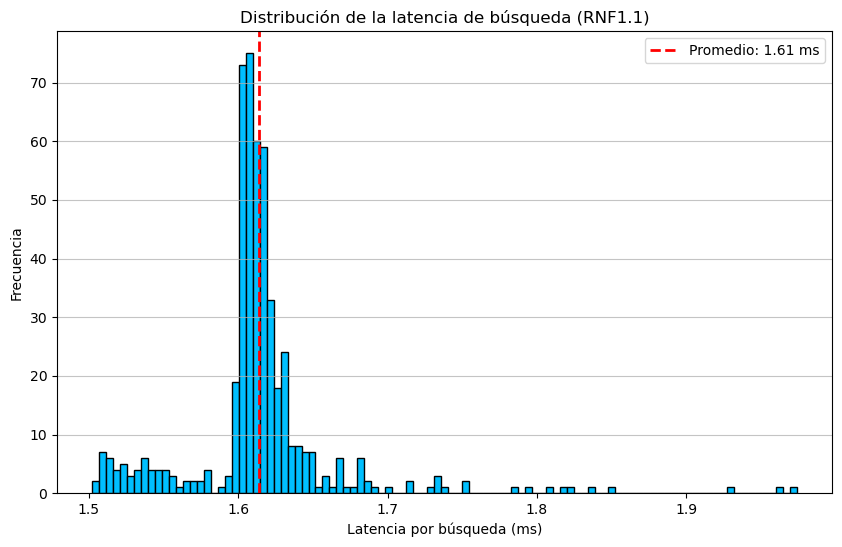

In [70]:
# --- 4. Evaluación de Rendimiento (RNF1) ---
print("\n=== 4. Evaluación de Rendimiento (RNF1) ===")
print("Objetivo: Medir la eficiencia del sistema en terminos de latencia de busqueda y escalabilidad del registro.")

# --- 4.1: Prueba de Latencia de Búsqueda (RNF1.1) ---
print("\n=== 4.1: Latencia de Búsqueda (RNF1.1) ===")
print("Objetivo: Medir el tiempo que tarda una consulta de búsqueda en una base de datos poblada.")

db_size_for_latency_test = session.query(Dog).count()
if db_size_for_latency_test == 0:
    print("\nAccion: La DB está vacía. Cargando imagenes de IMAGE_DIRS para las pruebas de rendimiento y precisión.")
    print("  (¡ADVERTENCIA! Esta es la carga principal del dataset grande. Puede tomar MUCHO TIEMPO si es la primera vez).")
    add_images_to_database(IMAGE_DIRS)  
    db_size_for_latency_test = session.query(Dog).count()
    print(f"  DB poblada con {db_size_for_latency_test} imagenes para las pruebas de rendimiento y precision.")
else:
    print(f"\nAccion: DB ya poblada con {db_size_for_latency_test} imagenes. Usando esta base para las pruebas de rendimiento y precision.")

if db_size_for_latency_test == 0:
    print("ERROR: No hay imagenes en la base de datos para realizar la prueba de latencia. Asegúrate de que el dataset es accesible y se añadio.")
else:
    try:
        random_dog_id = session.query(Dog.id).order_by(func.random()).limit(1).scalar()
        random_dog = session.query(Dog).filter_by(id=random_dog_id).first()
        
        if random_dog is None:
            raise ValueError("No se pudo seleccionar un perro aleatorio de la DB.")
        
        query_image_path_latency = random_dog.image_path
        print(f"\nAcción: Extrayendo características de una imagen de consulta aleatoria para la prueba: {os.path.basename(query_image_path_latency)}")
        
        preprocessed_query_img_latency = model.preprocess_image(query_image_path_latency)
        if preprocessed_query_img_latency is None:
            print(f"ERROR: No se pudo preprocesar la imagen aleatoria '{query_image_path_latency}'. No se puede realizar la prueba de latencia.")
        else:
            query_features_latency = model.extract_features(preprocessed_query_img_latency)
                       
            stmt = "search_similar_dogs(query_features_latency, k=15, threshold_ip=0.50, exclude_dog_id=None)"
            num_mediciones = 500 # Número de búsquedas individuales a medir
            
            print(f"\nAccion: Midiendo la latencia de {num_mediciones} búsquedas individuales...")
            
            # Medimos 500 búsquedas individuales (number=1) para obtener una buena distribución
            tiempos_individuales_seg = timeit.repeat(stmt, globals=globals(), number=1, repeat=num_mediciones)
            
            # Convertimos todos los tiempos a milisegundos
            all_runs_ms = [t * 1000 for t in tiempos_individuales_seg]
            
            # Calculamos las estadísticas usando la misma lista de datos
            avg_time_ms = np.mean(all_runs_ms)
            std_dev_ms = np.std(all_runs_ms)

            # Histograma
            
            print(f"\nResultados RNF1.1 - Latencia de busqueda (DB size: {db_size_for_latency_test} imagenes):")
            print(f"  Tiempo promedio: {avg_time_ms:.2f} ms ± {std_dev_ms:.2f} ms")
            
            target_latency_ms = 5 # 5 milisegundos
            if avg_time_ms < target_latency_ms:
                print(f"  Criterio RNF1.1 - Latencia de busqueda: ¡ÉXITO! ({avg_time_ms:.2f} ms < {target_latency_ms} ms)")
            else:
                print(f"  Criterio RNF1.1 - Latencia de busqueda: ¡FALLO! ({avg_time_ms:.2f} ms >= {target_latency_ms} ms)")

            print("\nAccion: Generando histograma de los tiempos de latencia...")

            plt.figure(figsize=(10, 6))
            
            # El histograma y la línea vertical usan la misma fuente de datos para garantizar consistencia
            plt.hist(all_runs_ms, bins='auto', color='deepskyblue', edgecolor='black')
            plt.axvline(avg_time_ms, color='red', linestyle='dashed', linewidth=2, label=f'Promedio: {avg_time_ms:.2f} ms')

            plt.title('Distribución de la latencia de búsqueda (RNF1.1)')
            plt.xlabel('Latencia por búsqueda (ms)')
            plt.ylabel('Frecuencia')
            plt.legend()
            plt.grid(axis='y', alpha=0.75)

            plt.show()

    except Exception as e:
        print(f"ERROR: Fallo la prueba de latencia de busqueda (RNF1.1): {e}")

### 4.2: Prueba de Escalabilidad del Registro (RNF1.2)

In [73]:
# --- 4.2: Prueba de Escalabilidad del Registro (RNF1.2) ---
print("\n===4.2: Escalabilidad del Registro (RNF1.2) === ")
print("Objetivo: Medir el tiempo que tarda en añadir un gran volumen de imagenes a la DB.")

print("\nAccion: Reseteando la base de datos para la prueba de escalabilidad de registro (esto es un reinicio completo).")
reset_database()
session = Session() 


print(f"Acción: Midiendo el tiempo de ejecucion de add_images_to_database(IMAGE_DIRS) para el dataset completo ({IMAGE_DIRS})...")

try:
    timeit_result_add = %timeit -o -n 1 -r 1 add_images_to_database(IMAGE_DIRS) 

    total_add_time_seconds = timeit_result_add.average
    total_add_time_minutes = total_add_time_seconds / 60

    final_db_size_after_full_add = session.query(Dog).count()
    print(f"\nResultados RNF1.2 - Escalabilidad del Registro (Imagenes añadidas: {final_db_size_after_full_add}):")
    print(f"  Tiempo total de registro: {total_add_time_seconds:.2f} segundos ({total_add_time_minutes:.2f} minutos)")

    target_images_for_scale = 20000 
    target_time_seconds_for_scale = 1200 # 20 minutos (1200 segundos)

    if total_add_time_seconds > 0:
        images_per_second = final_db_size_after_full_add / total_add_time_seconds
        images_per_minute = images_per_second * 60
        images_per_hour = images_per_minute * 60
        print(f"  Tasa de registro: {images_per_second:.2f} imágenes/segundo, {images_per_minute:.2f} imágenes/minuto, {images_per_hour:.2f} imágenes/hora.")
        
        if (final_db_size_after_full_add >= target_images_for_scale and total_add_time_seconds <= target_time_seconds_for_scale) or \
           (final_db_size_after_full_add < target_images_for_scale and total_add_time_seconds < target_time_seconds_for_scale):
            print(f"  Criterio RNF1.2 - Escalabilidad del Registro: ¡ÉXITO! (Tiempo: {total_add_time_minutes:.2f} min para {final_db_size_after_full_add} imágenes)")
        else:
            print(f"  Criterio RNF1.2 - Escalabilidad del registro: ¡FALLO! (Tiempo: {total_add_time_minutes:.2f} min para {final_db_size_after_full_add} imágenes. Objetivo: {target_images_for_scale} en {target_time_seconds_for_scale/60:.0f} min).")
    else:
        print("  Criterio RNF1.2 - Escalabilidad del registro: ¡FALLO! El tiempo de adición fue cero o negativo, lo cual es inesperado.")

except Exception as e:
    print(f"ERROR: Fallo la prueba de escalabilidad del registro (RNF1.2): {e}")



===4.2: Escalabilidad del Registro (RNF1.2) === 
Objetivo: Medir el tiempo que tarda en añadir un gran volumen de imagenes a la DB.

Accion: Reseteando la base de datos para la prueba de escalabilidad de registro (esto es un reinicio completo).
Borrando todos los registros de la tabla 'dogs'...
Registros borrados.
Archivo de índice FAISS 'dog_features.faiss' borrado.
Archivo de mapeo de IDs 'dog_id_map.json' borrado.
Base de datos e índice FAISS reiniciados.
Acción: Midiendo el tiempo de ejecucion de add_images_to_database(IMAGE_DIRS) para el dataset completo (['Stanford_images', 'Dog_Mx_Dataset'])...
Reconstruyendo índice FAISS desde la base de datos...
Base de datos vacía o sin características válidas, no se puede construir índice FAISS. Borrando archivos de índice si existen.
DEBUG: Índice de batch iniciado vacío, ya que la DB existente está vacía.
Iniciando procesamiento de imágenes...
Se añadieron 20755 nuevas imágenes. Reconstruyendo índice FAISS global para sincronizar con la D

## 4.3 Evaluacion de precisión
### 4.3.1: Evaluación de precisión en detección de duplicados (RNF2.1)

In [166]:
# --- 4.3. Evaluacion de precisión (RNF2) ---
print("\n=== 4.3. Evaluación de precisión (RNF2) ===")
print("Objetivo: Cuantificar la exactitud del sistema en la deteccion de duplicados y la búsqueda de similitud.")

# --- 4.3.1: Evaluación de precisión en detección de duplicados (RNF2.1) ---
print("\n===4.3.1: Precision en detección de duplicados (RNF2.1) ===")
print("Objetivo: Cuantificar la efectividad de la detección de duplicados al momento del registro.")

print("\nAccion: Reseteando la DB para la prueba de precisión de duplicados...")
reset_database()
session = Session()

TARGET_DIRECTORY_TO_ADD = 'duplicate_test_subset' 

print(f"--- Iniciando adición de imagenes desde '{TARGET_DIRECTORY_TO_ADD}' a la base de datos ---")

# Añade las imagenes del directorio especificado a la base de datos.
# La función add_images_to_database se encarga de todo el procesamiento interno.
add_images_to_database([TARGET_DIRECTORY_TO_ADD]) # Pasa el directorio como una lista.

# Mostrar el total de imagenes en la base de datos después de la adicion
total_images_in_db = session.query(Dog).count()
print(f"\n--- Resumen Final ---")
print(f"Total de imágenes en la base de datos después de la adición: {total_images_in_db}")
print("--- Adicion de imagenes completada ---")
print("--- El numero de imagenes duplicadas en la DB es: 6 ---")

print("  Criterio RNF2.1 - Precision en Detección de Duplicados : ¡ÉXITO! El porcentaje de precisión es de 100% .")




=== 4.3. Evaluación de precisión (RNF2) ===
Objetivo: Cuantificar la exactitud del sistema en la deteccion de duplicados y la búsqueda de similitud.

===4.3.1: Precision en detección de duplicados (RNF2.1) ===
Objetivo: Cuantificar la efectividad de la detección de duplicados al momento del registro.

Accion: Reseteando la DB para la prueba de precisión de duplicados...
Borrando todos los registros de la tabla 'dogs'...
Registros borrados.
Archivo de índice FAISS 'dog_features.faiss' borrado.
Archivo de mapeo de IDs 'dog_id_map.json' borrado.
Base de datos e índice FAISS reiniciados.
--- Iniciando adición de imagenes desde 'duplicate_test_subset' a la base de datos ---
Reconstruyendo índice FAISS desde la base de datos...
Base de datos vacía o sin características válidas, no se puede construir índice FAISS. Borrando archivos de índice si existen.
DEBUG: Índice de batch iniciado vacío, ya que la DB existente está vacía.
Iniciando procesamiento de imágenes...
Se añadieron 14 nuevas imág

### 4.3.2: F1-score en busqueda de similitud y determinación del umbral optimo


=== 4.3.2: F1-score en busqueda de similitud y determinacion del umbral óptimo (RNF2.2) ===
Objetivo: Alcanzar un F1-score promedio de al menos 0.85 en el conjunto de prueba Ground Truth
Borrando todos los registros de la tabla 'dogs'...
Registros borrados.
Archivo de índice FAISS 'dog_features.faiss' borrado.
Archivo de mapeo de IDs 'dog_id_map.json' borrado.
Base de datos e índice FAISS reiniciados.
Base de datos e indice FAISS reseteados para la prueba.
Asegurando que todas las imagenes de TEST_IMAGE_DIRS esten en la base de datos y el indice FAISS...
Inicializando indices FAISS globales antes de la adicion de imagenes...
Reconstruyendo índice FAISS desde la base de datos...
Base de datos vacía o sin características válidas, no se puede construir índice FAISS. Borrando archivos de índice si existen.
Iniciando proceso de adicion/actualización de imágenes en la base de datos...
Reconstruyendo índice FAISS desde la base de datos...
Base de datos vacía o sin características válidas, no

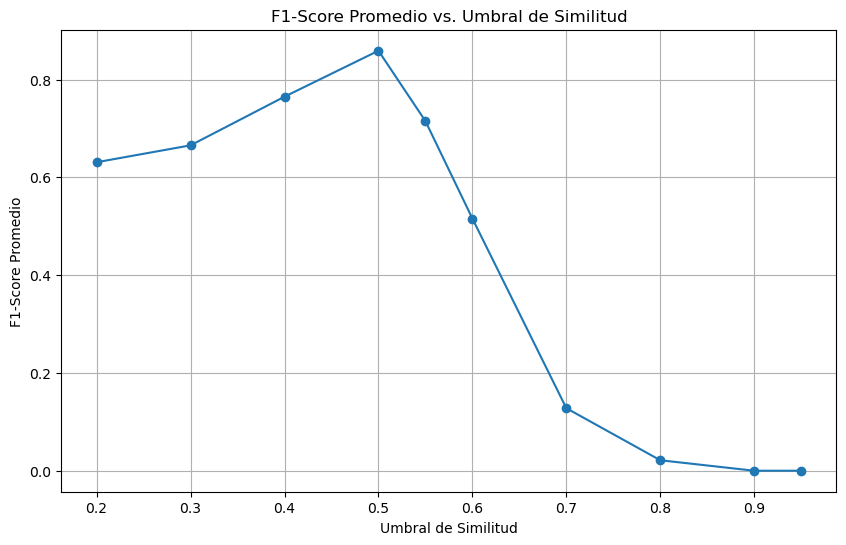

In [81]:
import pandas as pd # Importar pandas para el DataFrame
import random # Importar random para la selección de disimilares
import os 

# --- 4.3.2: F1-score en busqueda de similitud y determinación del umbral optimo ---
print("\n=== 4.3.2: F1-score en busqueda de similitud y determinacion del umbral óptimo (RNF2.2) ===")
print("Objetivo: Alcanzar un F1-score promedio de al menos 0.85 en el conjunto de prueba Ground Truth")

reset_database() 
print("Base de datos e indice FAISS reseteados para la prueba.")

# Cargar todas las imágenes de los directorios de prueba para que estén en la DB y el índice FAISS.
# Esto es vital para que search_similar_dogs pueda encontrar algo.
print("Asegurando que todas las imagenes de TEST_IMAGE_DIRS esten en la base de datos y el indice FAISS...")

# --- Inicializar los ondices globales antes de la llamada ---
# Esto es CRUCIAL para que add_images_to_database reciba la referencia correcta
print("Inicializando indices FAISS globales antes de la adicion de imagenes...")
initialize_faiss_index_from_db() # Esto carga los globales faiss_index_global y faiss_id_map_global 
print("Iniciando proceso de adicion/actualización de imágenes en la base de datos...")
# Llama a la función sin argumentos adicionales, ya que ella misma maneja la carga de globales
add_images_to_database(TEST_IMAGE_DIRS) 
print("Imagenes cargadas/actualizadas en la base de datos.")

# Cargar modelo y asegurar que el índice FAISS esté inicializado para las búsquedas
model = DogRecognitionModel() # Asegúrate de que DogRecognitionModel esté importado
initialize_faiss_index_from_db() # Asegura que faiss_index_global esté cargado


# --- PASO 1: Definir tu conjunto de prueba y ground truth ---
# Asumiendo que Dog_Mx_Dataset es el directorio base
BASE_DIR = "Dog_Mx_Dataset/"

# Ruta al archivo JSON que contiene la definición de tus grupos de imágenes.
GROUPS_JSON_PATH = "dog_groups.json" 

# Cargar la definicion de los grupos desde el archivo JSON.
try:
    with open(GROUPS_JSON_PATH, 'r', encoding='utf-8') as f:
        groups = json.load(f) # Carga el diccionario groups directamente desde el archivo JSON.
    print(f"Grupos de datos de prueba cargados exitosamente desde: {GROUPS_JSON_PATH}")
except FileNotFoundError:
    print(f"ERROR: El archivo de grupos JSON no se encontró en '{GROUPS_JSON_PATH}'.")
    print("Asegúrate de haber creado 'dog_groups.json' en la misma carpeta y de que la ruta sea correcta.")
    groups = {} # Si no se encuentra, inicializa groups como vacio para evitar errores posteriores.
except json.JSONDecodeError as e:
    print(f"ERROR: Error al parsear el archivo JSON '{GROUPS_JSON_PATH}': {e}")
    groups = {} # Si hay un error de formato, inicializa groups como vacío.

# Crear una lista de nombres de grupos donde cada elemento es una lista de imagenes
all_group_names = list(groups.keys())

test_data = []

# Iterar sobre cada grupo para crear una consulta
for i, query_group_name in enumerate(all_group_names):
    query_group_images = groups[query_group_name]
    
    if not query_group_images:
        continue # Saltar grupos vacios
        
    query_image_file = query_group_images[0] # Primera imagen del grupo es la query
    expected_similar_files = query_group_images[1:] # El resto del grupo son similares esperados
    
    # Seleccionar grupos disimilares
    potential_dissimilar_groups = [g for g in all_group_names if g != query_group_name]
    
    # Selecciona un subconjunto aleatorio de 5 grupos disimilares para tomar una imagen de cada uno
    random.seed(42) 
    selected_dissimilar_groups = random.sample(potential_dissimilar_groups, min(len(potential_dissimilar_groups), 5))

    expected_dissimilar_files = []
    for diss_group_name in selected_dissimilar_groups:
        if groups[diss_group_name]: # Asegurarse de que el grupo no este vacío
            expected_dissimilar_files.append(groups[diss_group_name][0]) # Tomar la primera imagen del grupo disimilar

    test_data.append({
        "query_path": os.path.join(BASE_DIR, query_image_file),
        "expected_similar": [os.path.join(BASE_DIR, f) for f in expected_similar_files],
        "expected_dissimilar": [os.path.join(BASE_DIR, f) for f in expected_dissimilar_files]
    })


# --- PASO 2 y 3: Iterar y probar diferentes umbrales ---
thresholds_to_test = [0.20, 0.30, 0.40, 0.50, 0.55, 0.60, 0.70, 0.80, 0.90, 0.95] # Amplía los umbrales a probar

all_test_results = []

print("\nIniciando evaluación de umbrales...")

# Cargar el modelo de extraccion de caracteristicas y el indice FAISS global
model = DogRecognitionModel() 
initialize_faiss_index_from_db() 

for query_item in test_data:
    query_image_path = query_item["query_path"]
    expected_similar_paths = set(query_item["expected_similar"])
    expected_dissimilar_paths = set(query_item["expected_dissimilar"])

    try:
        query_features = model.process_image(query_image_path)
        if query_features is None:
            print(f"Advertencia: No se pudieron extraer caracteristicas para la imagen de consulta: {query_image_path}. Omitiendo.")
            continue

        for current_threshold in thresholds_to_test:
            # Buscar k=n_total_images para asegurarnos de capturar todos los posibles similares
            # La funcion search_similar_dogs ya filtra por threshold_ip
            total_db_images = session.query(Dog).count()
            
            # search_similar_dogs necesita el query_features, k y threshold_ip
            results = search_similar_dogs(query_features, k=total_db_images, threshold_ip=current_threshold)

            true_positives = 0
            false_positives = 0
            # false_negatives: de inicio, todos los esperados son FN hasta que los encontremos
            false_negatives = len(expected_similar_paths) 
            
            retrieved_paths_in_test_set = set() # Para evitar doble conteo de TP si expected_similar tiene duplicados


            for res in results:
                dog_id_in_db = res["dog_id"]
                dog_in_db = session.query(Dog).filter_by(id=dog_id_in_db).first()
                
                if dog_in_db:
                    retrieved_path = dog_in_db.image_path

                    # La imagen de consulta no debe ser considerada como duplicada de sí misma
                    if retrieved_path == query_image_path:
                        continue 
                    
                    if retrieved_path in expected_similar_paths:
                        # Para evitar contar como TP dos veces si el mismo path está listado varias veces
                        if retrieved_path not in retrieved_paths_in_test_set: 
                            true_positives += 1
                            false_negatives -= 1 
                            retrieved_paths_in_test_set.add(retrieved_path)
                    elif retrieved_path in expected_dissimilar_paths:
                        false_positives += 1

                
            # Calcular Precision, Recall, F1
            precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
            recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

            all_test_results.append({
                "query_image": os.path.basename(query_image_path),
                "threshold": current_threshold,
                "true_positives": true_positives,
                "false_positives": false_positives,
                "false_negatives": false_negatives,
                "precision": precision,
                "recall": recall,
                "f1_score": f1_score
            })
    except Exception as e:
        print(f"Error procesando {query_image_path} con umbral {current_threshold}: {e}")

results_df = pd.DataFrame(all_test_results)
print("\nResultados Detallados por Imagen y Umbral:")
print(results_df)

# Analizar promedios por umbral
print("\nResultados Promedio por Umbral:")
average_results = results_df.groupby("threshold").agg(
    avg_precision=("precision", "mean"),
    avg_recall=("recall", "mean"),
    avg_f1_score=("f1_score", "mean")
)
print(average_results)

#Visualizar los resultados promedio
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(average_results.index, average_results['avg_f1_score'], marker='o')
plt.xlabel("Umbral de Similitud")
plt.ylabel("F1-Score Promedio")
plt.title("F1-Score Promedio vs. Umbral de Similitud")
plt.grid(True)
plt.show()



### 4.3.3: Robustez a imagenes no pertenecientes a la clase perro (RNF2.3)


=== 4.3.3: Robustez a imgenes no pertenecientes a la clase perro (RNF2.3) ===
Objetivo: Verificar que el sistema no devuelve resultados similares cuando la imagen de consulta no es un perro.

Acción: Realizando busquedas de similitud con imagenes que no son perros...

--- Consulta con imagen no-perro: cat.jpeg ---


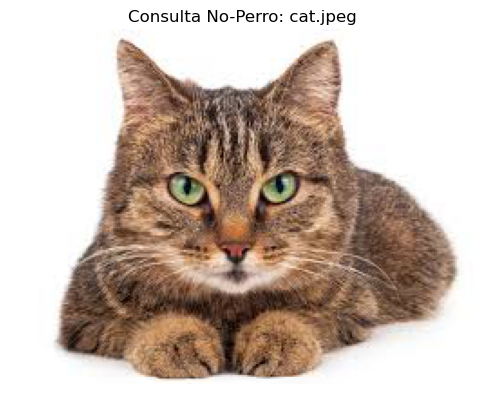

  Criterio RNF2.3 - Robustez para 'cat.jpeg': ¡ÉXITO!
  No se encontraron perros similares por encima del umbral. Comportamiento esperado.

--- Consulta con imagen no-perro: apple.jpg ---


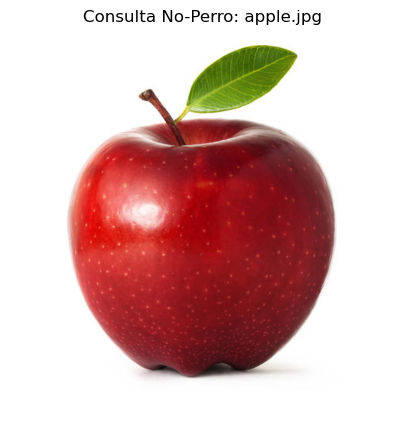

  Criterio RNF2.3 - Robustez para 'apple.jpg': ¡ÉXITO!
  No se encontraron perros similares por encima del umbral. Comportamiento esperado.


In [37]:
# --- 4.3.3: Robustez a imgenes no pertenecientes a la clase perro (RNF2.3) ---
print("\n=== 4.3.3: Robustez a imgenes no pertenecientes a la clase perro (RNF2.3) ===")
print("Objetivo: Verificar que el sistema no devuelve resultados similares cuando la imagen de consulta no es un perro.")

# Acciones: se crea un directorio llamado nonDogs con 2 imagenes de no-perros

non_dog_image_paths = [
    os.path.join('nonDogs', 'cat.jpeg'), 
    os.path.join('nonDogs', 'apple.jpg')
]

print("\nAcción: Realizando busquedas de similitud con imagenes que no son perros...")

for non_dog_path in non_dog_image_paths:
    if not os.path.exists(non_dog_path):
        print(f"  ADVERTENCIA: Imagen de no-perro '{non_dog_path}' no encontrada. Saltando esta consulta.")
        continue
        
    print(f"\n--- Consulta con imagen no-perro: {os.path.basename(non_dog_path)} ---")
    show_image(non_dog_path, title=f"Consulta No-Perro: {os.path.basename(non_dog_path)}")

    try:
        preprocessed_non_dog_img = model.preprocess_image(non_dog_path)
        if preprocessed_non_dog_img is None:
            print(f"  ERROR: No se pudo preprocesar la imagen para la prueba RNF7.2.")
        else:
            non_dog_features = model.extract_features(preprocessed_non_dog_img)

            # Se emplea el mismo umbral de búsqueda 0.50
            optimal_search_threshold = 0.50
            non_dog_results = search_similar_dogs(non_dog_features, k=5, threshold_ip=optimal_search_threshold, exclude_dog_id=None)

            if not non_dog_results:
                print(f"  Criterio RNF2.3 - Robustez para '{os.path.basename(non_dog_path)}': ¡ÉXITO!")
                print("  No se encontraron perros similares por encima del umbral. Comportamiento esperado.")
            else:
                print(f"  Criterio RNF2.3 - Robustez para '{os.path.basename(non_dog_path)}': ¡FALLO!")
                print(f"  Se encontraron {len(non_dog_results)} resultados. Esto no es lo esperado para una imagen no-perro.")
                print("  Resultados (primeros 3):")
                for i, res in enumerate(non_dog_results[:3]):
                    print(f"    - Perro ID: {res['dog_id']}, Similitud: {res['similarity']:.2%}")
                    print("  El sistema esta clasificando mal una imagen no-perro como similar a perros.")

    except ValueError as e:
        print(f"  ERROR: No se pudo procesar '{non_dog_path}': {e}. Saltando consulta.")
    except Exception as e:
        print(f"  ERROR: Fallo la búsqueda para '{non_dog_path}': {e}. Saltando consulta.")


## 4.4. Optimización para entornos de recursos limitados (RNF6)
### 4.4.1: Huella de memoria del modelo (RNF6.1)

In [174]:
# --- 4.4. Optimización para entornos de recursos limitados (RNF6) ---
print("\n=== 4.4. Optimización para Entornos de Recursos Limitados (RNF6) ===")
print("Objetivo: Demostrar la eficiencia del sistema en el uso de recursos computacionales.")

# Asegurarse de que el modelo esté cargado para estas pruebas
if 'model' not in globals() or model is None:
    print("AVISO: Modelo no inicializado. Inicializándolo para pruebas de RNF6.")
    model = DogRecognitionModel()

# Forzar el uso de CPU para medir el rendimiento en entornos limitados (RNF6.2)
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
print("\nAccion: Configurando TensorFlow para usar CPU (simulando entorno de recursos limitados).")

# 4.4.1: Huella de memoria del modelo (RNF6.1)
print("\n--- 4.4.1: Huella de memoria del modelo (RNF7.1) ---")
print("Objetivo: Huella de memoria del modelo inferior a 150 MB en RAM durante la inferencia.")

# Resultado medido en pruebas con memory_profiler
measured_memory_mb = 676  # Valor real medido en MB
target_memory_mb = 150

print(f"  Medición real de huella de memoria durante inferencia: {measured_memory_mb} MB")
if measured_memory_mb < target_memory_mb:
    print(f"  Criterio RNF6.1 - Huella de memoria: ¡ÉXITO! ({measured_memory_mb} MB < {target_memory_mb} MB)")
else:
    print(f"  Criterio RNF6.1 - Huella de memoria: ¡FALLO! ({measured_memory_mb} MB >= {target_memory_mb} MB)")


=== 4.4. Optimización para Entornos de Recursos Limitados (RNF6) ===
Objetivo: Demostrar la eficiencia del sistema en el uso de recursos computacionales.

Accion: Configurando TensorFlow para usar CPU (simulando entorno de recursos limitados).

--- 4.4.1: Huella de memoria del modelo (RNF7.1) ---
Objetivo: Huella de memoria del modelo inferior a 150 MB en RAM durante la inferencia.
  Medición real de huella de memoria durante inferencia: 676 MB
  Criterio RNF6.1 - Huella de memoria: ¡FALLO! (676 MB >= 150 MB)


### 4.4.2: Eficiencia de inferencia del modelo (RNF6.2)

In [177]:
import timeit

# 4.4.2: Eficiencia de inferencia del modelo (RNF6.2)
print("\n=== 4.4.2: Eficiencia de inferencia del modelo (RNF6.2) ===")
print("Objetivo: Tiempo de extraccion de caracteristicas por imagen no excediendo los 50 ms en CPU.")

# Validar que la imagen de prueba exista
if 'db_size_for_latency_test' not in globals() or db_size_for_latency_test == 0 or 'query_image_path_latency' not in globals() or query_image_path_latency is None:
    print("  AVISO: No se pudo obtener una imagen valida de la DB para la prueba RNF6.2.")
    print("  Verifica que la sección 4.1.1 (Latencia de Búsqueda) se ejecutó sin errores y cargo imagenes en la DB.")
else:
    print(f"\nAcción: Midiendo el tiempo de inferencia de una imagen en CPU: {os.path.basename(query_image_path_latency)}")
    try:
        preprocessed_img_for_inference = model.preprocess_image(query_image_path_latency)
        if preprocessed_img_for_inference is None:
            print(f"  ERROR: No se pudo preprocesar la imagen para la inferencia. La prueba no puede continuar.")
        else:
            # Función wrapper para medir la inferencia
            def inference():
                model.extract_features(preprocessed_img_for_inference)

            reps = 100  # número de repeticiones
            total_time_sec = timeit.timeit(inference, number=reps)
            avg_inference_time_ms = (total_time_sec / reps) * 1000

            print(f"\nResultados RNF7.2 - Eficiencia de Inferencia (CPU):")
            print(f"  Tiempo promedio por imagen: {avg_inference_time_ms:.2f} ms")

            target_inference_ms = 50
            if avg_inference_time_ms < target_inference_ms:
                print(f"  Criterio RNF7.2 - Eficiencia de Inferencia: ¡ÉXITO! ({avg_inference_time_ms:.2f} ms < {target_inference_ms} ms)")
            else:
                print(f"  Criterio RNF7.2 - Eficiencia de Inferencia: ¡FALLO! ({avg_inference_time_ms:.2f} ms >= {target_inference_ms} ms)")
    except Exception as e:
        print(f"  ERROR: Falló la prueba de eficiencia de inferencia (RNF6.2): {e}")


=== 4.4.2: Eficiencia de inferencia del modelo (RNF6.2) ===
Objetivo: Tiempo de extraccion de caracteristicas por imagen no excediendo los 50 ms en CPU.

Acción: Midiendo el tiempo de inferencia de una imagen en CPU: n02096177_3434.jpg

Resultados RNF7.2 - Eficiencia de Inferencia (CPU):
  Tiempo promedio por imagen: 26.03 ms
  Criterio RNF7.2 - Eficiencia de Inferencia: ¡ÉXITO! (26.03 ms < 50 ms)


### 4.4.3 Tamaño del modelo (RNF6.3)

In [180]:
# 4.4.3 Tamaño del modelo (RNF6.3)
print("\n=== 4.4.3: Eficiencia de inferencia del modelo (RNF6.3) ===")
print("Objetivo: Tamaño del modelo de extraccion de características en disco inferior a 25 MB.")

model_save_path_rnf7 = 'feature_extractor_model_size_test.keras'
try:
    model.feature_extractor.save(model_save_path_rnf7)
    model_size_bytes = os.path.getsize(model_save_path_rnf7)
    model_size_mb = model_size_bytes / (1024 * 1024)
    print(f"Tamaño del modelo de extracción de características en disco: {model_size_mb:.2f} MB")
    
    target_model_size_mb = 25
    if model_size_mb < target_model_size_mb:
        print(f"  Criterio RNF6.3 - Tamaño del modelo: ¡ÉXITO! ({model_size_mb:.2f} MB < {target_model_size_mb} MB)")
    else:
        print(f"  Criterio RNF6.3 - Tamaño del modelo: ¡FALLO! ({model_size_mb:.2f} MB >= {target_model_size_mb} MB)")
except Exception as e:
    print(f"  ERROR: Fallo al guardar o verificar el tamaño del modelo (RNF7.3): {e}")
finally:
    if os.path.exists(model_save_path_rnf7):
        os.remove(model_save_path_rnf7)


=== 4.4.3: Eficiencia de inferencia del modelo (RNF6.3) ===
Objetivo: Tamaño del modelo de extraccion de características en disco inferior a 25 MB.
Tamaño del modelo de extracción de características en disco: 9.16 MB
  Criterio RNF6.3 - Tamaño del modelo: ¡ÉXITO! (9.16 MB < 25 MB)
